# Tarefa 13 — Distribuições de Probabilidade Aplicadas às Ciências dos Alimentos

## Distribuições Normal, t de Student, Qui-quadrado e F de Fisher

**Disciplina:** Estatística / Probabilidade  
**Curso:** Ciências dos Alimentos  

### Integrantes
**Karin Santos**- N° USP: 15674699

**Larissa Taffarel**- N° USP: 14669771  

**Laura Damásio**- N° USP: 13658280

### Base de dados
Wine Quality — UCI Machine Learning Repository

**Data de acesso:** 04/10/2026

## Objetivo

Este trabalho tem como objetivo estudar e aplicar as distribuições Normal,
t de Student, Qui-quadrado e F de Fisher utilizando uma base de dados real
da área de alimentos.

Será utilizada a base Wine Quality, que contém resultados de análises
físico-químicas e sensoriais de amostras de vinhos portugueses.

Ao longo do trabalho serão investigados:

- o comportamento teórico das quatro distribuições;
- os parâmetros que determinam seus formatos;
- aplicações relacionadas às características físico-químicas dos vinhos;
- probabilidades acumuladas;
- probabilidades entre dois valores;
- probabilidades acima de determinado valor;
- percentis;
- comportamento das médias e variâncias;
- comparação da variabilidade entre grupos.

A análise busca relacionar conceitos de probabilidade e inferência estatística
com situações reais das Ciências dos Alimentos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, t, chi2, f

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

## Base de dados — Wine Quality

A base utilizada neste trabalho é a **Wine Quality**, disponibilizada pelo
UCI Machine Learning Repository.

Ela contém resultados referentes a amostras de vinhos do tipo Vinho Verde,
produzidos no norte de Portugal.

Existem dois conjuntos de dados:

- vinho tinto;
- vinho branco.

Cada linha representa uma amostra de vinho analisada.

As variáveis de entrada correspondem a resultados de análises
físico-químicas, enquanto a variável `quality` corresponde a uma avaliação
sensorial da qualidade do vinho.

### Instituição responsável

UCI Machine Learning Repository.

### Autores da base

Paulo Cortez, A. Cerdeira, F. Almeida, T. Matos e J. Reis.

### Data de acesso

04 de outubro de 2026.

### Dados ausentes

Segundo a documentação oficial da UCI, a base não apresenta valores
ausentes. Mesmo assim, essa informação será verificada utilizando Python.

### Critério de seleção

A base foi selecionada porque:

1. pertence ao contexto de alimentos e bebidas;
2. apresenta observações individuais;
3. contém variáveis físico-químicas quantitativas;
4. possui dois grupos de produtos — vinho tinto e vinho branco;
5. permite estudar médias e variâncias;
6. permite aplicar as quatro distribuições propostas na atividade.

### Variáveis da base

| Variável | Significado | Unidade |
|---|---|---|
| fixed acidity | Acidez fixa | g ácido tartárico/dm³ |
| volatile acidity | Acidez volátil | g ácido acético/dm³ |
| citric acid | Ácido cítrico | g/dm³ |
| residual sugar | Açúcar residual | g/dm³ |
| chlorides | Cloretos | g NaCl/dm³ |
| free sulfur dioxide | Dióxido de enxofre livre | mg/dm³ |
| total sulfur dioxide | Dióxido de enxofre total | mg/dm³ |
| density | Densidade | g/cm³ |
| pH | pH | adimensional |
| sulphates | Sulfatos | g sulfato de potássio/dm³ |
| alcohol | Teor alcoólico | % vol. |
| quality | Qualidade sensorial | escore de 0 a 10 |

In [ ]:
url_red = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)

url_white = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-white.csv"
)

red = pd.read_csv(url_red, sep=";")
white = pd.read_csv(url_white, sep=";")

red["wine_type"] = "Tinto"
white["wine_type"] = "Branco"

print("Vinhos tintos:", len(red))
print("Vinhos brancos:", len(white))

Vinhos tintos: 1599
Vinhos brancos: 4898


In [ ]:
dados = pd.concat([red, white], ignore_index=True)

print("Total de observações:", len(dados))
print("Número de variáveis:", dados.shape[1])

dados.head()

Total de observações: 6497
Número de variáveis: 13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Tinto


In [ ]:
dados.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


A análise confirma que não existem valores ausentes nas variáveis utilizadas.
Portanto, não foi necessária imputação ou exclusão de observações por dados
faltantes.

In [ ]:
dados.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
dados.groupby("wine_type")["alcohol"].agg(
    ["count", "mean", "median", "std", "var", "min", "max"]
)

,count,mean,median,std,var,min,max
wine_type,,,,,,,
Branco,4898,10.514267,10.4,1.230621,1.514427,8.0,14.2
Tinto,1599,10.422983,10.2,1.065668,1.135647,8.4,14.9


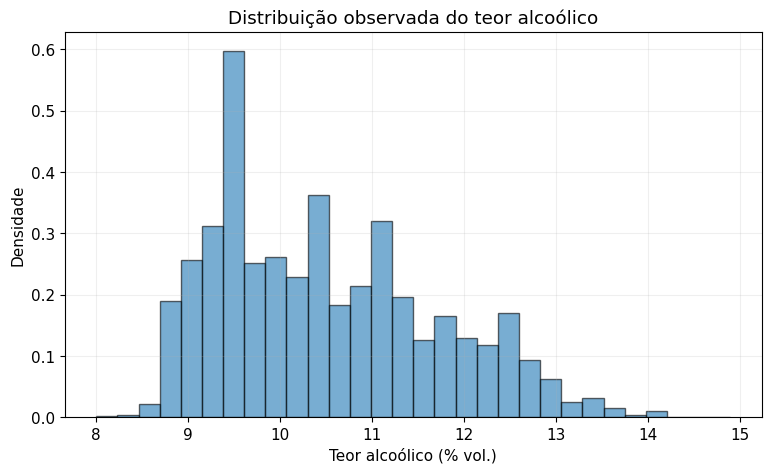

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    dados["alcohol"],
    bins=30,
    density=True,
    alpha=0.6,
    edgecolor="black"
)

plt.xlabel("Teor alcoólico (% vol.)")
plt.ylabel("Densidade")
plt.title("Distribuição observada do teor alcoólico")
plt.grid(alpha=0.2)
plt.show()

## Distribuição Normal

A distribuição Normal é uma distribuição contínua, simétrica e em formato
de sino.

Ela é determinada por dois parâmetros:

- μ (mu): média da distribuição;
- σ (sigma): desvio-padrão.

A função densidade é:

\[
f(x)=
\frac{1}{\sigma\sqrt{2\pi}}
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
\]

onde:

- x representa um possível valor da variável;
- μ representa a média;
- σ representa o desvio-padrão;
- σ² representa a variância;
- e é a base do logaritmo natural;
- π é a constante pi.

O parâmetro μ determina a posição central da curva.

O parâmetro σ determina sua dispersão. Valores maiores de σ produzem
curvas mais espalhadas, enquanto valores menores produzem curvas mais
concentradas em torno da média.

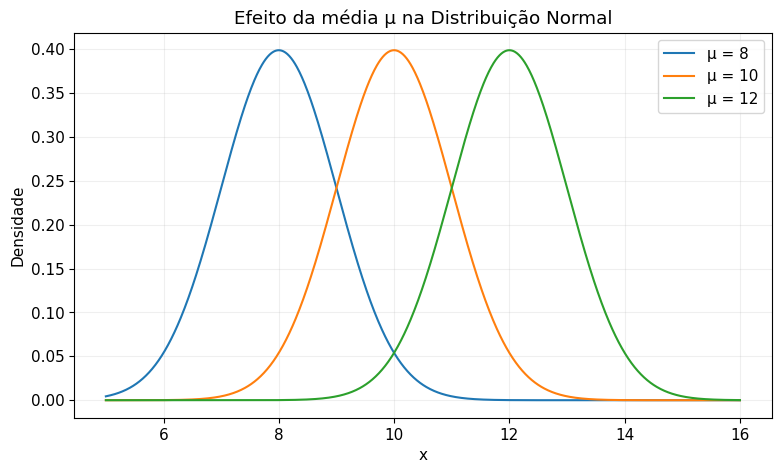

In [ ]:
x = np.linspace(5, 16, 1000)

sigma = 1
medias = [8, 10, 12]

plt.figure(figsize=(9, 5))

for mu in medias:
    plt.plot(
        x,
        norm.pdf(x, loc=mu, scale=sig qr ma),
        label=f"μ = {mu}"
    )

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Efeito da média μ na Distribuição Normal")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Ao modificar μ mantendo σ constante, a curva é deslocada horizontalmente,
mas seu formato e sua dispersão permanecem iguais.

Portanto, μ determina principalmente a localização do centro da distribuição.

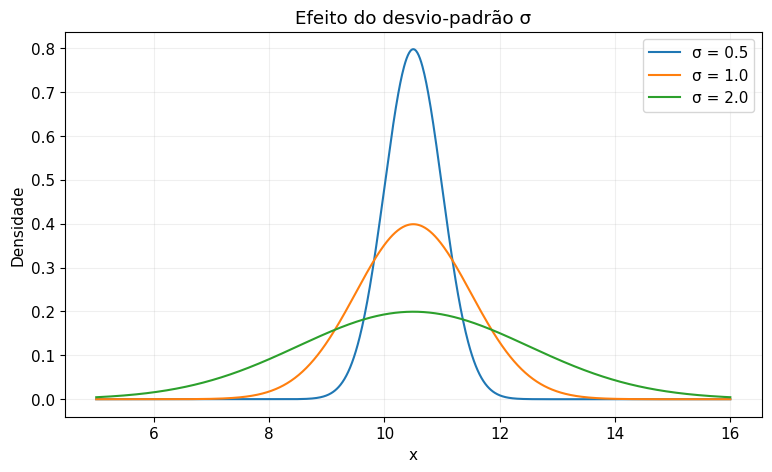

In [ ]:
x = np.linspace(5, 16, 1000)

mu = 10.5
sigmas = [0.5, 1.0, 2.0]

plt.figure(figsize=(9, 5))

for sigma in sigmas:
    plt.plot(
        x,
        norm.pdf(x, loc=mu, scale=sigma),
        label=f"σ = {sigma}"
    )

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Efeito do desvio-padrão σ")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Quando σ aumenta, os valores ficam mais dispersos em relação à média,
fazendo com que a curva fique mais larga e menos alta.

Quando σ diminui, os valores ficam mais concentrados próximos da média,
produzindo uma curva mais estreita e alta.



Considerando o teor alcoólico observado na base como aproximadamente
Normal, qual é a probabilidade associada a diferentes faixas de teor
alcoólico das amostras analisadas?




In [ ]:
alcool = dados["alcohol"]

mu = alcool.mean()
sigma = alcool.std(ddof=1)

print(f"Média = {mu:.3f}% vol.")
print(f"Desvio-padrão = {sigma:.3f}% vol.")

Média = 10.492% vol.
Desvio-padrão = 1.193% vol.


In [ ]:
x_limite = 10

p_acumulada = norm.cdf(
    x_limite,
    loc=mu,
    scale=sigma
)

print(f"P(X ≤ {x_limite}) = {p_acumulada:.4f}")
print(f"Probabilidade = {p_acumulada*100:.2f}%")

P(X ≤ 10) = 0.3400
Probabilidade = 34.00%


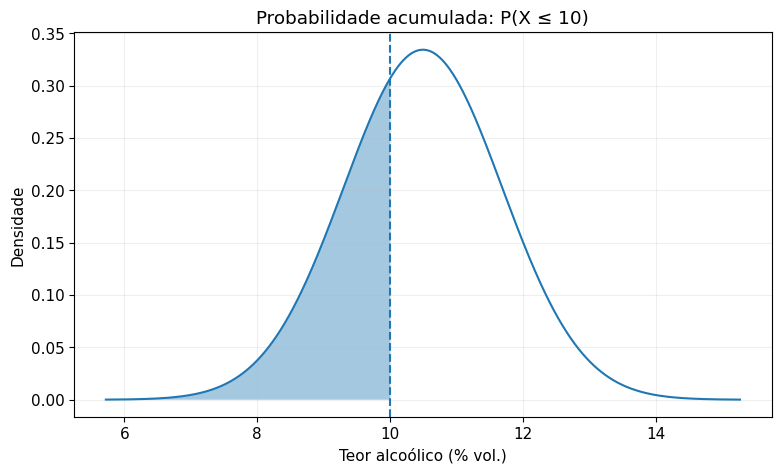

In [ ]:
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(9, 5))
plt.plot(x, y)

mask = x <= 10

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4
)

plt.axvline(10, linestyle="--")

plt.xlabel("Teor alcoólico (% vol.)")
plt.ylabel("Densidade")
plt.title("Probabilidade acumulada: P(X ≤ 10)")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
limite = 12

p_acima = norm.sf(
    limite,
    loc=mu,
    scale=sigma
)

print(f"P(X > {limite}) = {p_acima:.4f}")
print(f"Probabilidade = {p_acima*100:.2f}%")

P(X > 12) = 0.1030
Probabilidade = 10.30%


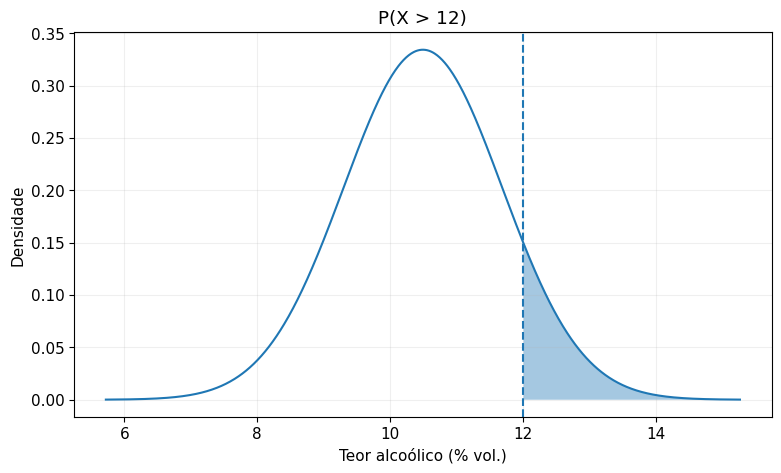

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(x, y)

mask = x >= limite

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4
)

plt.axvline(limite, linestyle="--")

plt.xlabel("Teor alcoólico (% vol.)")
plt.ylabel("Densidade")
plt.title("P(X > 12)")
plt.grid(alpha=0.2)
plt.show()

Qual teor alcoólico corresponde ao percentil 90 da distribuição Normal
ajustada aos dados?

In [ ]:
percentil_90 = norm.ppf(
    0.90,
    loc=mu,
    scale=sigma
)

print(f"Percentil 90 = {percentil_90:.3f}% vol.")

Percentil 90 = 12.020% vol.


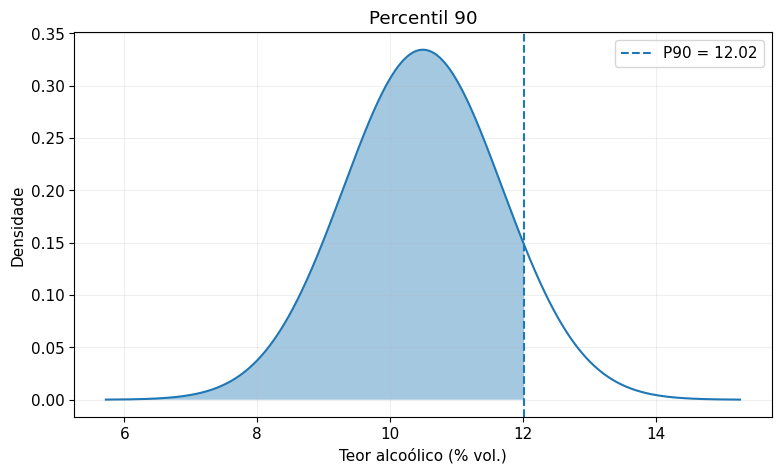

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(x, y)

mask = x <= percentil_90

plt.fill_between(
    x[mask],
    y[mask],
    alpha=0.4
)

plt.axvline(
    percentil_90,
    linestyle="--",
    label=f"P90 = {percentil_90:.2f}"
)

plt.xlabel("Teor alcoólico (% vol.)")
plt.ylabel("Densidade")
plt.title("Percentil 90")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

O percentil 90 representa o valor abaixo do qual se encontram 90% dos
valores previstos pelo modelo Normal ajustado.

Assim, apenas aproximadamente 10% da distribuição teórica apresenta valores
superiores a esse ponto.

### Condições e limitações da Distribuição Normal

A aplicação da distribuição Normal pressupõe que a variável analisada tenha
comportamento aproximadamente simétrico e contínuo.

Neste trabalho, os parâmetros μ e σ foram estimados a partir das observações
de teor alcoólico.

Entretanto, utilizar uma distribuição Normal não significa afirmar que os
dados reais seguem perfeitamente essa distribuição. Assimetria, valores
extremos, mistura de diferentes populações e outros fatores podem provocar
desvios em relação ao modelo teórico.

Além disso, a base reúne vinhos tintos e brancos, que podem apresentar
características diferentes. Portanto, a distribuição ajustada ao conjunto
completo deve ser interpretada como uma aproximação.

Os cálculos apresentados correspondem às probabilidades previstas pelo
modelo Normal ajustado, e não simplesmente às proporções empíricas
observadas na amostra.

## Distribuição t de Student

A distribuição t de Student é contínua, simétrica e centrada em zero em sua
forma padronizada.

Ela apresenta formato semelhante ao da distribuição Normal, porém possui
caudas mais pesadas.

Sua densidade é:

\[
f(t)=
\frac{\Gamma((\nu+1)/2)}
{\sqrt{\nu\pi}\Gamma(\nu/2)}
\left(1+\frac{t^2}{\nu}\right)^{-(\nu+1)/2}
\]

onde:

- t é o valor da variável;
- ν representa os graus de liberdade;
- Γ representa a função gama;
- π representa a constante pi.

Para uma amostra utilizada na inferência sobre uma média, normalmente:

\[
\nu=n-1
\]

A estatística associada à média é:

\[
T=
\frac{\bar X-\mu_0}{S/\sqrt{n}}
\]

A distribuição t é particularmente importante quando a variância
populacional é desconhecida e precisa ser estimada pela amostra.

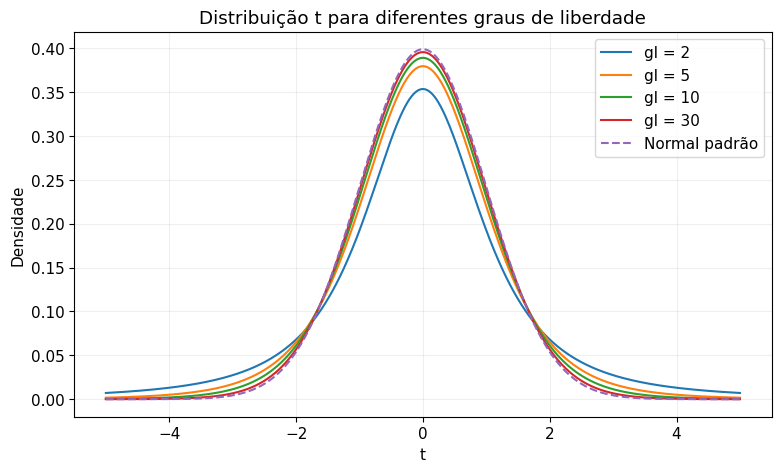

In [ ]:
x_t = np.linspace(-5, 5, 1000)

dfs = [2, 5, 10, 30]

plt.figure(figsize=(9, 5))

for df in dfs:
    plt.plot(
        x_t,
        t.pdf(x_t, df),
        label=f"gl = {df}"
    )

plt.plot(
    x_t,
    norm.pdf(x_t),
    linestyle="--",
    label="Normal padrão"
)

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title("Distribuição t para diferentes graus de liberdade")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Com poucos graus de liberdade, a distribuição t possui caudas mais pesadas.

À medida que os graus de liberdade aumentam, a incerteza associada à
estimativa do desvio-padrão diminui e a distribuição t se aproxima da
Normal padrão.

### Pergunta aplicada

Considerando uma amostra de 25 vinhos da base, qual é o comportamento da
estatística t associada à média do teor alcoólico quando a variância
populacional é desconhecida?

In [ ]:
amostra = dados["alcohol"].sample(
    n=25,
    random_state=42
)

n = len(amostra)
media_amostra = amostra.mean()
s = amostra.std(ddof=1)

gl_t = n - 1

print("n =", n)
print(f"Média amostral = {media_amostra:.3f}")
print(f"Desvio-padrão amostral = {s:.3f}")
print("Graus de liberdade =", gl_t)

n = 25
Média amostral = 10.458
Desvio-padrão amostral = 1.291
Graus de liberdade = 24


In [ ]:
t0 = 1

p_t_acum = t.cdf(t0, gl_t)

print(f"P(T ≤ {t0}) = {p_t_acum:.4f}")

P(T ≤ 1) = 0.8364


In [ ]:
p_t_entre = (
    t.cdf(1, gl_t)
    - t.cdf(-1, gl_t)
)

print(f"P(-1 < T < 1) = {p_t_entre:.4f}")

P(-1 < T < 1) = 0.6727


In [ ]:
p_t_acima = t.sf(2, gl_t)

print(f"P(T > 2) = {p_t_acima:.4f}")

P(T > 2) = 0.0285


In [ ]:
t95 = t.ppf(0.95, gl_t)

print(f"Percentil 95 = {t95:.4f}")

Percentil 95 = 1.7109


In [ ]:
def grafico_t_area(a=None, b=None, titulo="Distribuição t"):
    x = np.linspace(-4, 4, 1000)
    y = t.pdf(x, gl_t)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y)

    if a is None:
        mask = x <= b
    elif b is None:
        mask = x >= a
    else:
        mask = (x >= a) & (x <= b)

    plt.fill_between(
        x[mask],
        y[mask],
        alpha=0.4
    )

    plt.xlabel("t")
    plt.ylabel("Densidade")
    plt.title(titulo)
    plt.grid(alpha=0.2)
    plt.show()

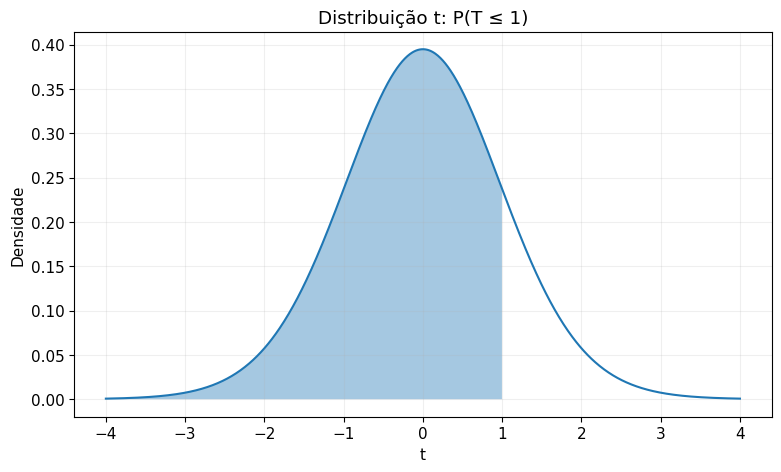

In [ ]:
grafico_t_area(
    b=1,
    titulo="Distribuição t: P(T ≤ 1)"
)

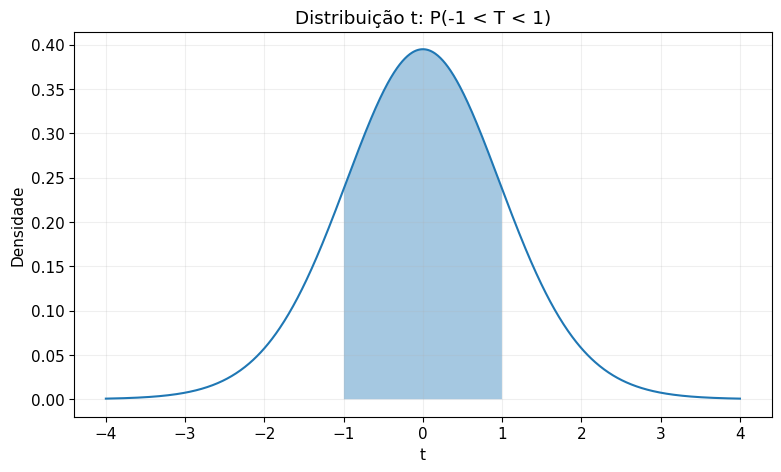

In [ ]:
grafico_t_area(
    a=-1,
    b=1,
    titulo="Distribuição t: P(-1 < T < 1)"
)

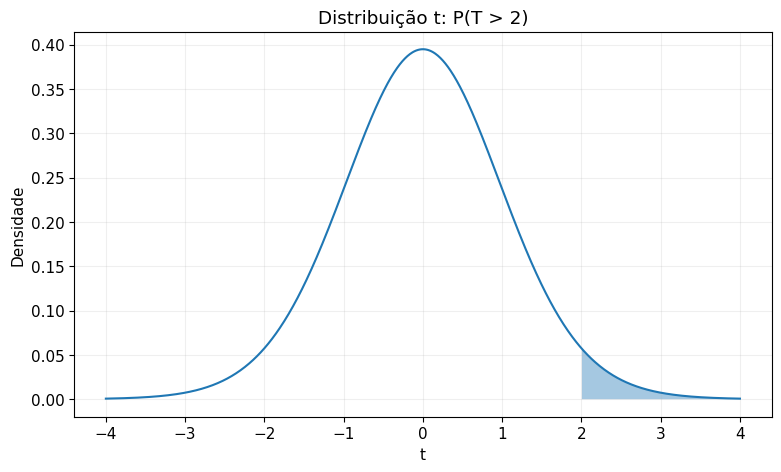

In [ ]:
grafico_t_area(
    a=2,
    titulo="Distribuição t: P(T > 2)"
)

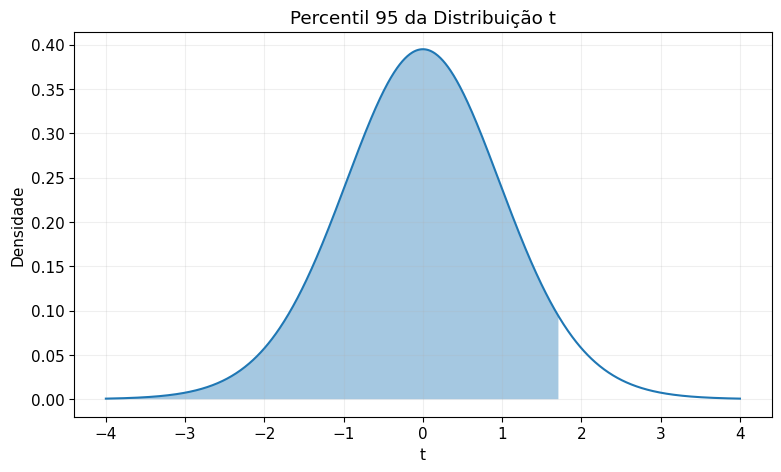

In [ ]:
grafico_t_area(
    b=t95,
    titulo="Percentil 95 da Distribuição t"
)

### Condições e limitações

A distribuição t é apropriada para inferências sobre médias quando o
desvio-padrão populacional é desconhecido e é substituído pelo
desvio-padrão amostral.

Entre as condições importantes estão:

- observações independentes;
- amostragem representativa;
- para amostras pequenas, população aproximadamente Normal;
- ausência de valores extremos muito influentes.

Para amostras maiores, a inferência sobre a média tende a ser mais robusta
a desvios moderados da Normalidade.

## Distribuição Qui-quadrado

A distribuição Qui-quadrado é contínua e assume somente valores
não negativos.

Sua função densidade é:

\[
f(x;k)=
\frac{1}
{2^{k/2}\Gamma(k/2)}
x^{k/2-1}e^{-x/2}
\]

para x > 0.

onde:

- x é o valor da variável Qui-quadrado;
- k representa os graus de liberdade;
- Γ representa a função gama.

Quando uma amostra aleatória é proveniente de uma população Normal, a
estatística relacionada à variância é:

\[
\chi^2 =
\frac{(n-1)S^2}{\sigma^2}
\]

e possui:

\[
k=n-1
\]

graus de liberdade.

Portanto, nesta aplicação a distribuição Qui-quadrado não está modelando
diretamente o teor alcoólico. Ela está modelando uma estatística relacionada
à variância.

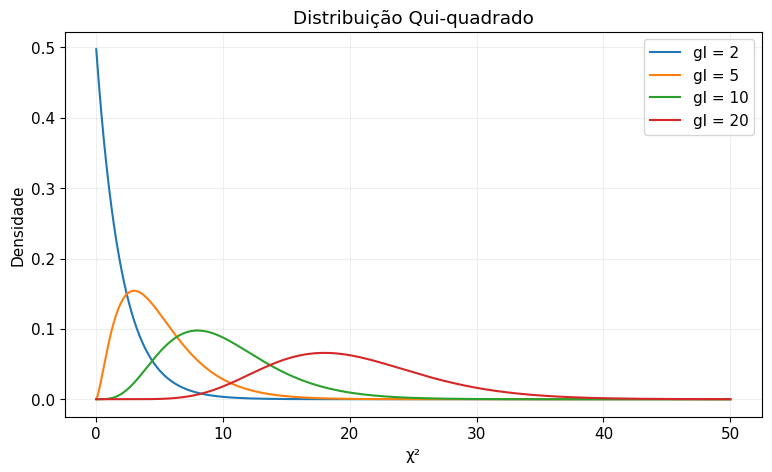

In [ ]:
x_chi = np.linspace(0.01, 50, 1000)

dfs_chi = [2, 5, 10, 20]

plt.figure(figsize=(9, 5))

for df in dfs_chi:
    plt.plot(
        x_chi,
        chi2.pdf(x_chi, df),
        label=f"gl = {df}"
    )

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title("Distribuição Qui-quadrado")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Para poucos graus de liberdade, a distribuição apresenta forte assimetria
à direita.

À medida que os graus de liberdade aumentam, a distribuição se torna menos
assimétrica e sua massa se desloca para valores maiores.



Considerando a variância do teor alcoólico, quais probabilidades podem ser
associadas à estatística Qui-quadrado para uma amostra de vinhos?

In [ ]:
gl_chi = n - 1

print("Graus de liberdade =", gl_chi)

Graus de liberdade = 24


In [ ]:
q = 20

p_chi_acum = chi2.cdf(q, gl_chi)

print(f"P(χ² ≤ {q}) = {p_chi_acum:.4f}")

P(χ² ≤ 20) = 0.3032


In [ ]:
a_chi = 15
b_chi = 30

p_chi_entre = (
    chi2.cdf(b_chi, gl_chi)
    - chi2.cdf(a_chi, gl_chi)
)

print(
    f"P({a_chi} < χ² < {b_chi}) = "
    f"{p_chi_entre:.4f}"
)

P(15 < χ² < 30) = 0.7360


In [ ]:
q = 30

p_chi_acima = chi2.sf(q, gl_chi)

print(f"P(χ² > {q}) = {p_chi_acima:.4f}")

P(χ² > 30) = 0.1848


In [ ]:
chi95 = chi2.ppf(0.95, gl_chi)

print(f"Percentil 95 = {chi95:.4f}")

Percentil 95 = 36.4150


In [ ]:
def grafico_chi_area(a=None, b=None, titulo="Qui-quadrado"):
    limite = chi2.ppf(0.999, gl_chi)

    x = np.linspace(0.001, limite, 1200)
    y = chi2.pdf(x, gl_chi)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y)

    if a is None:
        mask = x <= b
    elif b is None:
        mask = x >= a
    else:
        mask = (x >= a) & (x <= b)

    plt.fill_between(
        x[mask],
        y[mask],
        alpha=0.4
    )

    plt.xlabel("χ²")
    plt.ylabel("Densidade")
    plt.title(titulo)
    plt.grid(alpha=0.2)
    plt.show()

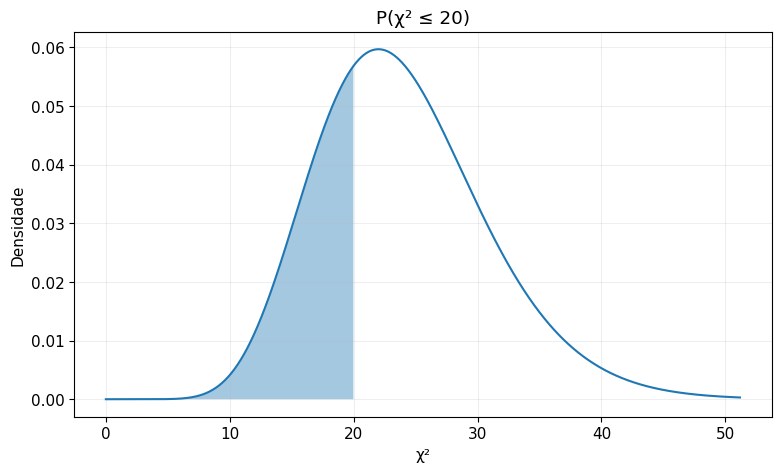

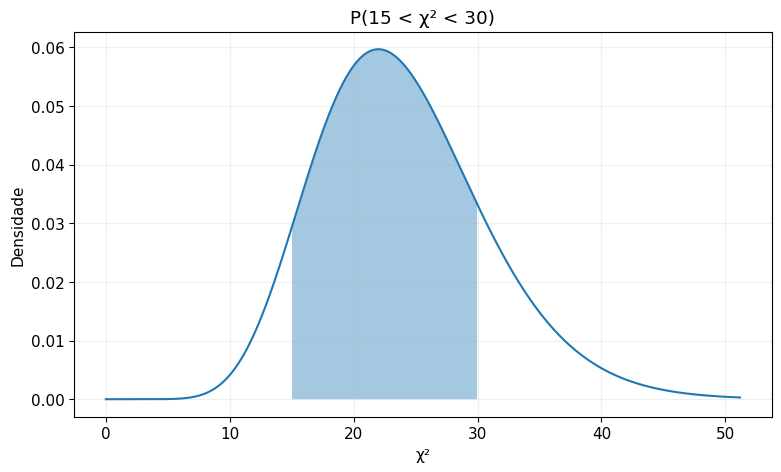

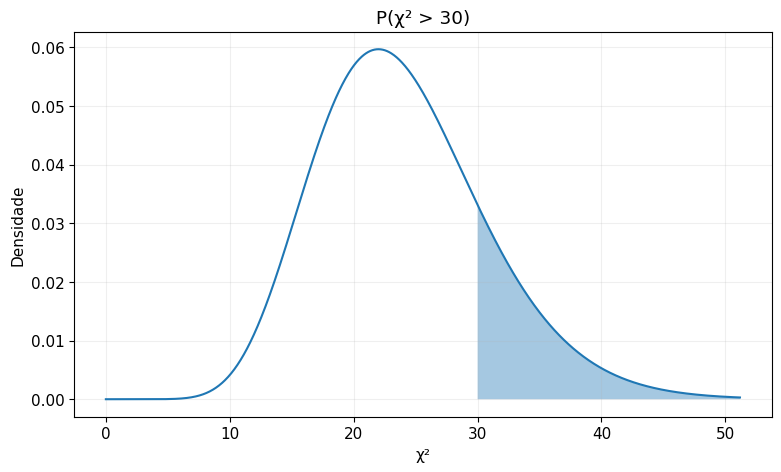

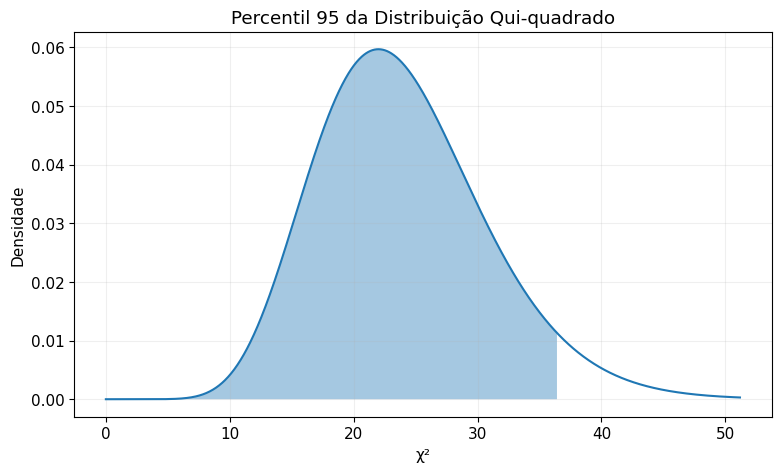

In [ ]:
grafico_chi_area(
    b=20,
    titulo="P(χ² ≤ 20)"
)

grafico_chi_area(
    a=15,
    b=30,
    titulo="P(15 < χ² < 30)"
)

grafico_chi_area(
    a=30,
    titulo="P(χ² > 30)"
)

grafico_chi_area(
    b=chi95,
    titulo="Percentil 95 da Distribuição Qui-quadrado"
)

### Condições e limitações

Na aplicação clássica da distribuição Qui-quadrado à variância, pressupõe-se
que:

- as observações sejam independentes;
- a amostra seja aleatória ou representativa;
- a população de origem seja aproximadamente Normal.

A última condição é especialmente importante para inferências exatas sobre
variância.

A distribuição Qui-quadrado não representa diretamente características como
teor alcoólico, pH ou acidez. Ela representa, neste contexto, uma estatística
construída a partir da variância amostral.

## Distribuição F de Fisher

A distribuição F é uma distribuição contínua definida para valores positivos
e é utilizada principalmente em problemas envolvendo razões de variâncias.

Sua função densidade pode ser escrita como:

\[
f(x;d_1,d_2)=
\frac{
d_2^{d_2/2}d_1^{d_1/2}x^{d_1/2-1}
}{
(d_2+d_1x)^{(d_1+d_2)/2}
B(d_1/2,d_2/2)
}
\]

para x > 0.

onde:

- x representa um possível valor da estatística F;
- d₁ representa os graus de liberdade do numerador;
- d₂ representa os graus de liberdade do denominador;
- B representa a função beta.

Para duas amostras independentes, uma estatística utilizada para comparar
variâncias é:

\[
F=\frac{S_1^2}{S_2^2}
\]

com:

\[
d_1=n_1-1
\]

e

\[
d_2=n_2-1.
\]

Assim, diferentemente da distribuição Normal, a F não está modelando
diretamente o teor alcoólico. Ela modela uma razão entre variâncias.

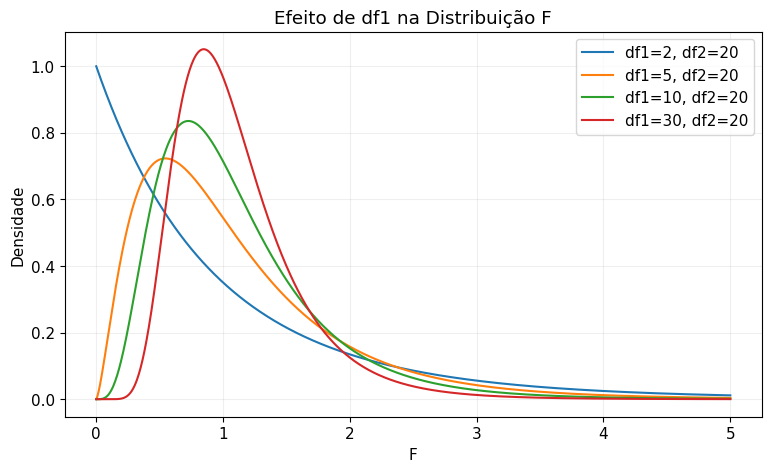

In [ ]:
x_f = np.linspace(0.001, 5, 1000)

df2_fixo = 20
df1_valores = [2, 5, 10, 30]

plt.figure(figsize=(9, 5))

for df1 in df1_valores:
    plt.plot(
        x_f,
        f.pdf(x_f, df1, df2_fixo),
        label=f"df1={df1}, df2={df2_fixo}"
    )

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Efeito de df1 na Distribuição F")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

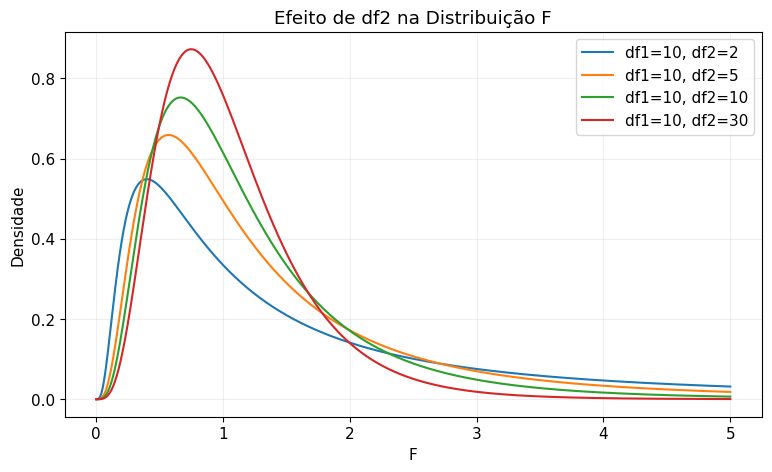

In [ ]:
df1_fixo = 10
df2_valores = [2, 5, 10, 30]

plt.figure(figsize=(9, 5))

for df2 in df2_valores:
    plt.plot(
        x_f,
        f.pdf(x_f, df1_fixo, df2),
        label=f"df1={df1_fixo}, df2={df2}"
    )

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Efeito de df2 na Distribuição F")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

A distribuição F apresenta assimetria positiva, com uma cauda à direita.

Quando os graus de liberdade são pequenos, a distribuição tende a apresentar
maior assimetria e cauda direita mais pronunciada.

Com o aumento dos graus de liberdade, a distribuição fica mais concentrada
em torno de valores próximos de 1 e a assimetria diminui.

Os dois graus de liberdade exercem papéis diferentes porque um está
associado à variância colocada no numerador e o outro à variância colocada
no denominador da razão.

In [ ]:
alcool_tinto = red["alcohol"].dropna()
alcool_branco = white["alcohol"].dropna()

print("Tintos:", len(alcool_tinto))
print("Brancos:", len(alcool_branco))

print(
    "Variância tintos:",
    alcool_tinto.var(ddof=1)
)

print(
    "Variância brancos:",
    alcool_branco.var(ddof=1)
)

Tintos: 1599
Brancos: 4898
Variância tintos: 1.1356473950004693
Variância brancos: 1.5144269817873444




A variabilidade do teor alcoólico dos vinhos tintos difere da variabilidade
do teor alcoólico dos vinhos brancos?

Para investigar essa questão, utilizamos as observações individuais dos dois
grupos e calculamos a razão entre suas variâncias amostrais.

In [ ]:
var_tinto = alcool_tinto.var(ddof=1)
var_branco = alcool_branco.var(ddof=1)

n_tinto = len(alcool_tinto)
n_branco = len(alcool_branco)

df1 = n_tinto - 1
df2 = n_branco - 1

F_obs = var_tinto / var_branco

print(f"Variância tinto = {var_tinto:.4f}")
print(f"Variância branco = {var_branco:.4f}")

print(f"F observado = {F_obs:.4f}")

print("df1 =", df1)
print("df2 =", df2)

Variância tinto = 1.1356
Variância branco = 1.5144
F observado = 0.7499
df1 = 1598
df2 = 4897


O valor F representa a razão entre as duas variâncias amostrais.

Um valor próximo de 1 indica variâncias de magnitudes semelhantes.

Valores afastados de 1 indicam maior diferença entre as variâncias, embora
a interpretação inferencial dependa dos graus de liberdade e da distribuição
F correspondente.

In [ ]:
p_F_acum = f.cdf(
    F_obs,
    df1,
    df2
)

print(f"P(F ≤ {F_obs:.4f}) = {p_F_acum:.4f}")

P(F ≤ 0.7499) = 0.0000


In [ ]:
F_a = 0.8
F_b = 1.2

p_F_entre = (
    f.cdf(F_b, df1, df2)
    - f.cdf(F_a, df1, df2)
)

print(
    f"P({F_a} < F < {F_b}) = "
    f"{p_F_entre:.4f}"
)

P(0.8 < F < 1.2) = 1.0000


In [ ]:
p_F_acima = f.sf(
    F_obs,
    df1,
    df2
)

print(f"P(F > {F_obs:.4f}) = {p_F_acima:.4f}")

P(F > 0.7499) = 1.0000


In [ ]:
F95 = f.ppf(
    0.95,
    df1,
    df2
)

print(f"Percentil 95 = {F95:.4f}")

Percentil 95 = 1.0686


In [ ]:
def grafico_f_area(a=None, b=None, titulo="Distribuição F"):
    limite = f.ppf(0.999, df1, df2)

    x = np.linspace(0.001, limite, 1500)
    y = f.pdf(x, df1, df2)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y)

    if a is None:
        mask = x <= b
    elif b is None:
        mask = x >= a
    else:
        mask = (x >= a) & (x <= b)

    plt.fill_between(
        x[mask],
        y[mask],
        alpha=0.4
    )

    plt.xlabel("F")
    plt.ylabel("Densidade")
    plt.title(titulo)
    plt.grid(alpha=0.2)
    plt.show()

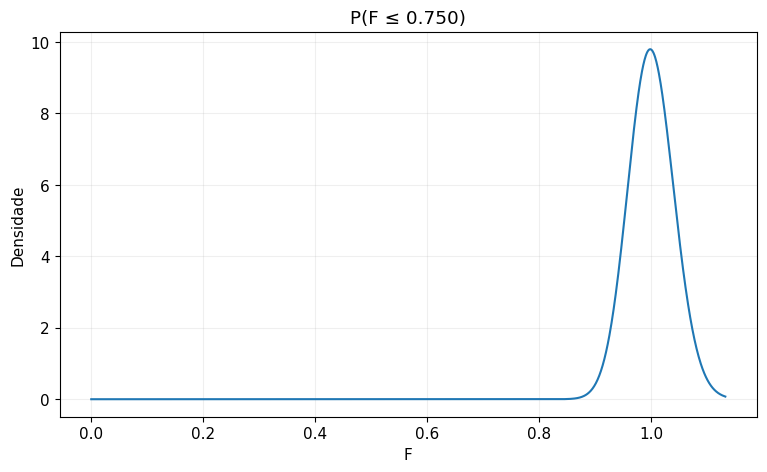

In [ ]:
grafico_f_area(
    b=F_obs,
    titulo=f"P(F ≤ {F_obs:.3f})"
)

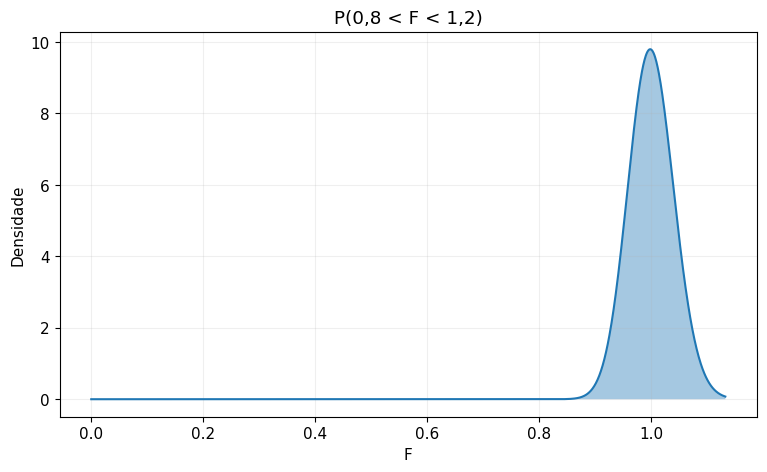

In [ ]:
grafico_f_area(
    a=0.8,
    b=1.2,
    titulo="P(0,8 < F < 1,2)"
)

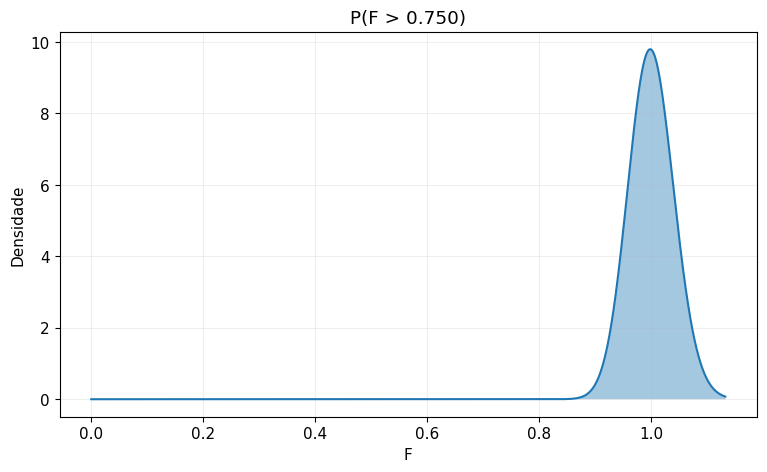

In [ ]:
grafico_f_area(
    a=F_obs,
    titulo=f"P(F > {F_obs:.3f})"
)

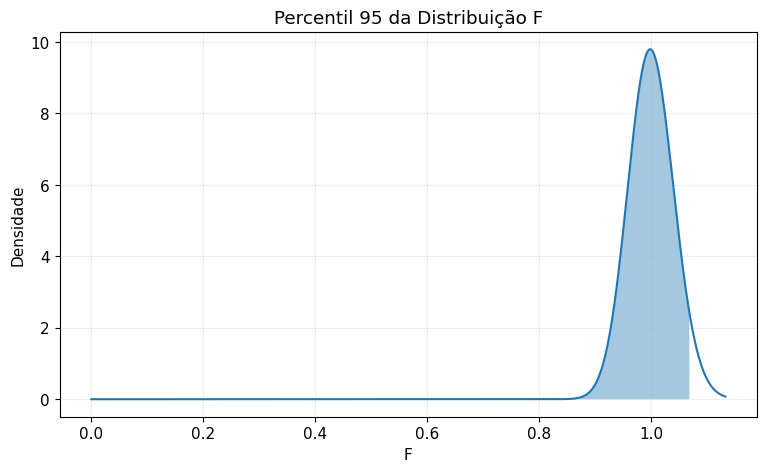

In [ ]:
grafico_f_area(
    b=F95,
    titulo="Percentil 95 da Distribuição F"
)

### Condições e limitações

Na aplicação clássica da distribuição F para comparar variâncias, algumas
condições são importantes:

- as duas amostras devem ser independentes;
- as observações dentro de cada grupo devem ser independentes;
- as populações devem apresentar distribuição aproximadamente Normal;
- a análise pode ser sensível a valores extremos e desvios de Normalidade.

Outra limitação importante deste trabalho é que a base contém apenas
informações físico-químicas e sensoriais disponibilizadas pelos autores.
Informações como produtor, variedade da uva e preço não estão disponíveis.

Portanto, as conclusões devem ser restritas às amostras e às variáveis
disponibilizadas na base.

## Comparação das distribuições

| Distribuição | O que está sendo modelado neste trabalho | Parâmetros principais |
|---|---|---|
| Normal | Valores de teor alcoólico | μ e σ |
| t de Student | Estatística relacionada à média amostral | graus de liberdade |
| Qui-quadrado | Estatística relacionada à variância | graus de liberdade |
| F de Fisher | Razão entre duas variâncias | df₁ e df₂ |

### Normal

Modela diretamente uma variável quantitativa contínua sob a suposição de
comportamento aproximadamente Normal. μ altera o centro da curva e σ altera
sua dispersão.

### t de Student

Está relacionada à inferência sobre uma média quando o desvio-padrão
populacional é desconhecido. Os graus de liberdade controlam principalmente
o peso das caudas.

### Qui-quadrado

Neste contexto, modela uma estatística relacionada à variância de uma
população Normal. Os graus de liberdade alteram sua localização e
assimetria.

### F de Fisher

Modela uma razão entre duas variâncias. Seu formato depende simultaneamente
dos graus de liberdade associados ao numerador e ao denominador.

## Conclusão

As quatro distribuições estudadas representam diferentes quantidades
estatísticas e, por isso, possuem aplicações distintas nas Ciências dos
Alimentos.

A distribuição Normal foi utilizada para modelar diretamente uma
característica físico-química contínua, o teor alcoólico dos vinhos. Seu
parâmetro μ determina o centro da distribuição, enquanto σ determina a
dispersão dos valores.

A distribuição t de Student foi relacionada à média amostral do teor
alcoólico quando a variabilidade populacional é desconhecida. Seu principal
parâmetro são os graus de liberdade. Com poucos graus de liberdade, a
distribuição apresenta caudas mais pesadas; conforme eles aumentam, a
distribuição se aproxima da Normal.

A distribuição Qui-quadrado foi utilizada no contexto da variância. Nesse
caso, ela não representa diretamente uma medida físico-química, mas uma
estatística construída a partir da variância amostral. O aumento dos graus
de liberdade reduz sua assimetria relativa e modifica sua localização e
dispersão.

A distribuição F de Fisher foi utilizada para estudar a razão entre as
variâncias do teor alcoólico dos vinhos tintos e brancos. Seu formato
depende dos graus de liberdade do numerador e do denominador e apresenta
assimetria à direita.

As áreas calculadas sob as curvas representam probabilidades previstas por
cada modelo. A probabilidade acumulada corresponde à área à esquerda de um
valor; a probabilidade entre dois valores corresponde à área delimitada por
eles; a probabilidade acima de um valor corresponde à área da cauda direita;
e o percentil representa o valor que deixa determinada proporção da
distribuição à sua esquerda.

Dessa forma, o trabalho demonstra que a escolha da distribuição depende da
quantidade que se deseja estudar: valores individuais, médias, variâncias
ou razões de variâncias. Essa distinção é fundamental para aplicar
corretamente métodos estatísticos na análise de dados de alimentos.

## Referências

CORTEZ, P.; CERDEIRA, A.; ALMEIDA, F.; MATOS, T.; REIS, J.
Modeling wine preferences by data mining from physicochemical properties.
Decision Support Systems, v. 47, n. 4, p. 547–553, 2009.

CORTEZ, P.; CERDEIRA, A.; ALMEIDA, F.; MATOS, T.; REIS, J.
Wine Quality [Dataset]. UCI Machine Learning Repository, 2009.
DOI: 10.24432/C56S3T.

UCI MACHINE LEARNING REPOSITORY.
Wine Quality Dataset.
Acesso em: 04 out. 2026.

SCIPY.
Statistical functions — scipy.stats.
Documentação das distribuições norm, t, chi2 e f.
Acesso em: 04 out. 2026.